<a href="https://colab.research.google.com/github/Nagilameher45/Major-Project-Artificial-Intelligence/blob/main/PROJECT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---------- LOAD RAW DATA ----------
df = pd.read_csv("/content/Cardi.csv")

# Fix the single-column issue (semicolon separated)
df = df.iloc[:,0].str.split(";", expand=True)

# Rename properly
df.columns = [
    "id", "age", "gender", "height", "weight",
    "ap_hi", "ap_lo", "cholesterol", "gluc",
    "smoke", "alco", "active", "cardio"
]

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

# ----- TARGET -----
X = df.drop(columns=["cardio", "id"])
y = df["cardio"]

# ------ SPLIT ------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------ SCALING ------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.7235714285714285


In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.6499285714285714


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.6284285714285714


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.7152857142857143


In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", acc_svm)


SVM Accuracy: 0.7319285714285715


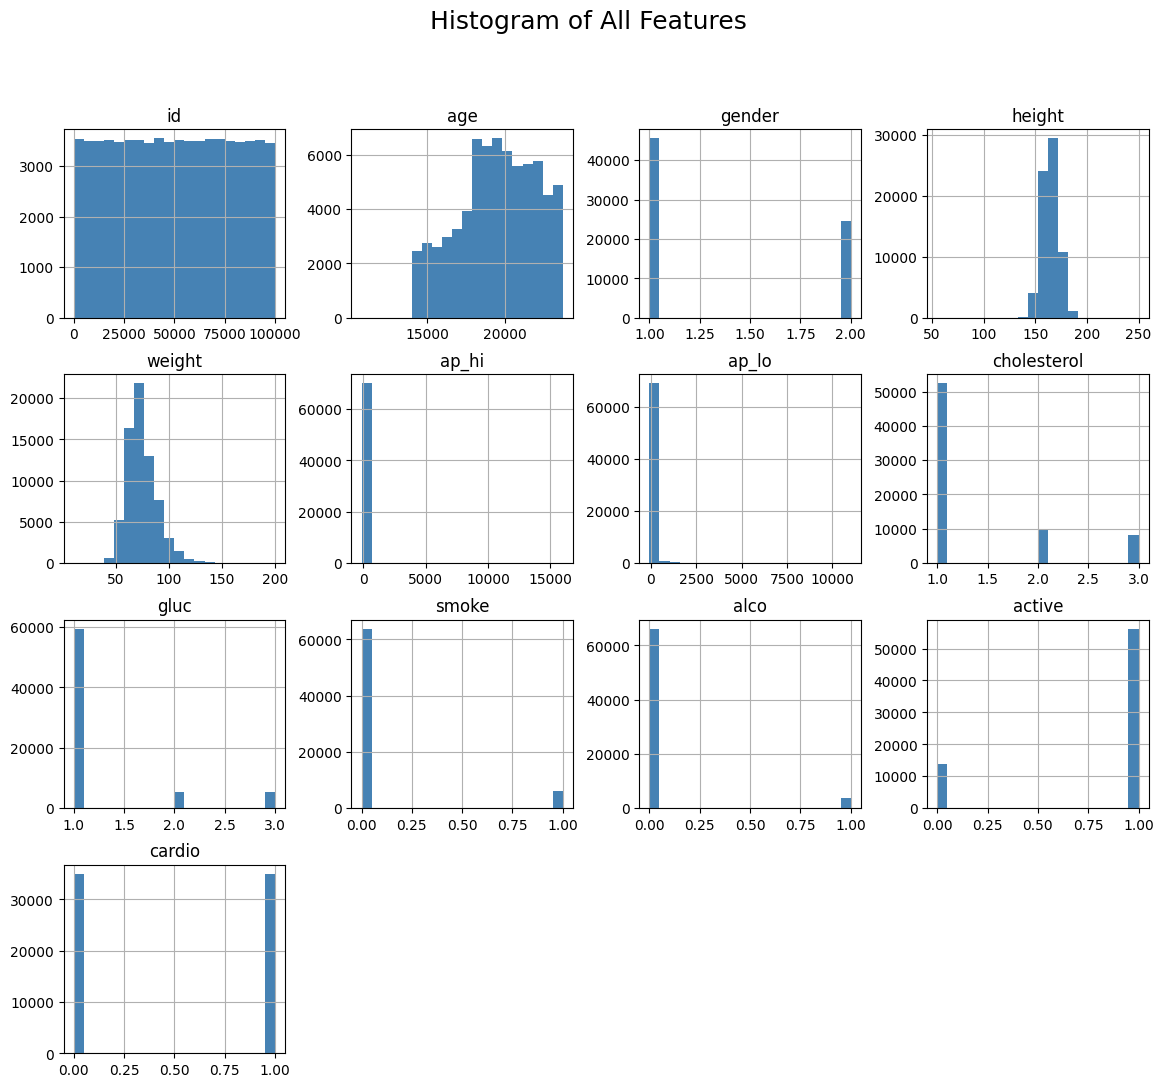

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df.hist(figsize=(14, 12), bins=20, color='steelblue')
plt.suptitle("Histogram of All Features", fontsize=18)
plt.show()

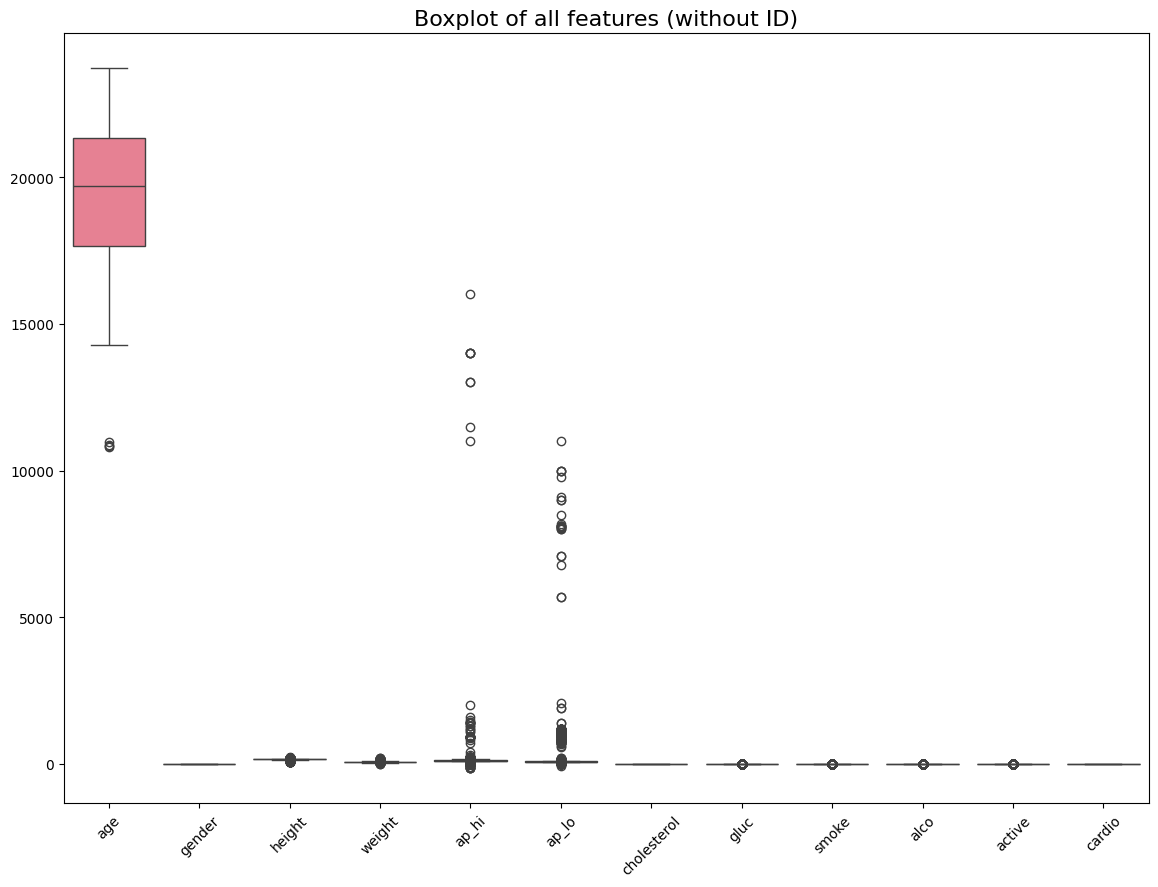

In [8]:
plt.figure(figsize=(14, 10))
sns.boxplot(data=df.drop(columns=["id"]))
plt.title("Boxplot of all features (without ID)", fontsize=16)
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-3739949842.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")
/tmp/ipython-input-3739949842.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")
/tmp/ipython-input-3739949842.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")
/tmp/ipython-input-3739949842.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the 

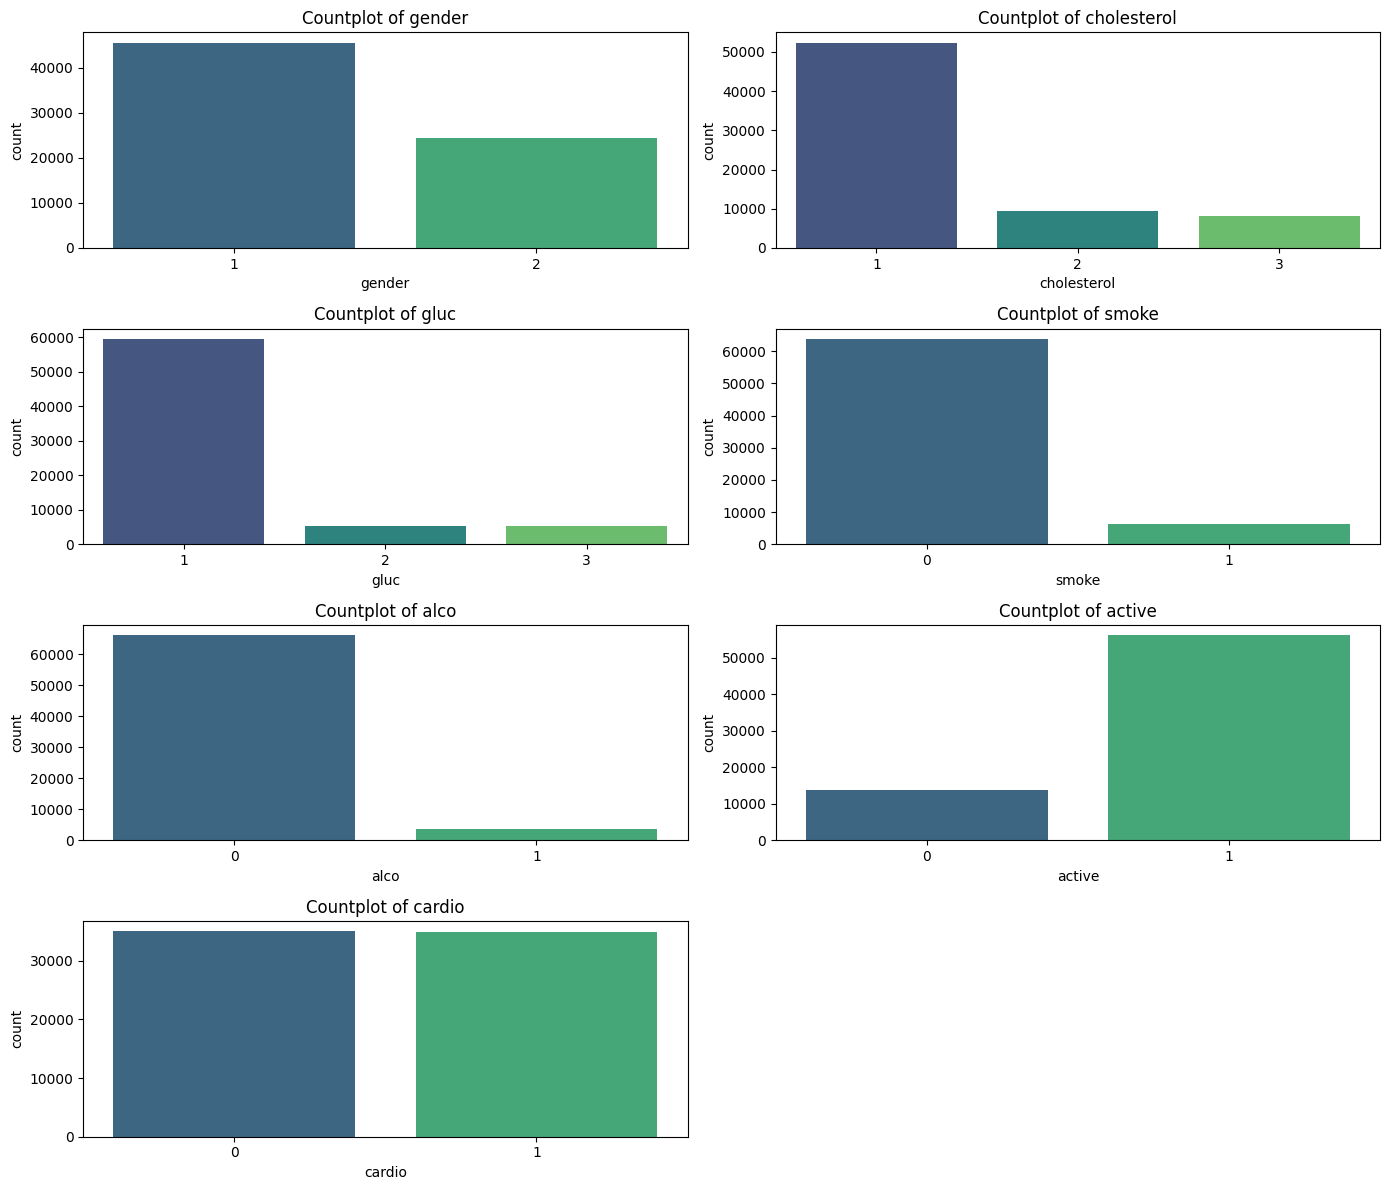

In [9]:
categorical_features = ["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]

plt.figure(figsize=(14, 12))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(4, 2, i)
    sns.countplot(x=df[col], palette="viridis")
    plt.title(f"Countplot of {col}")
plt.tight_layout()
plt.show()

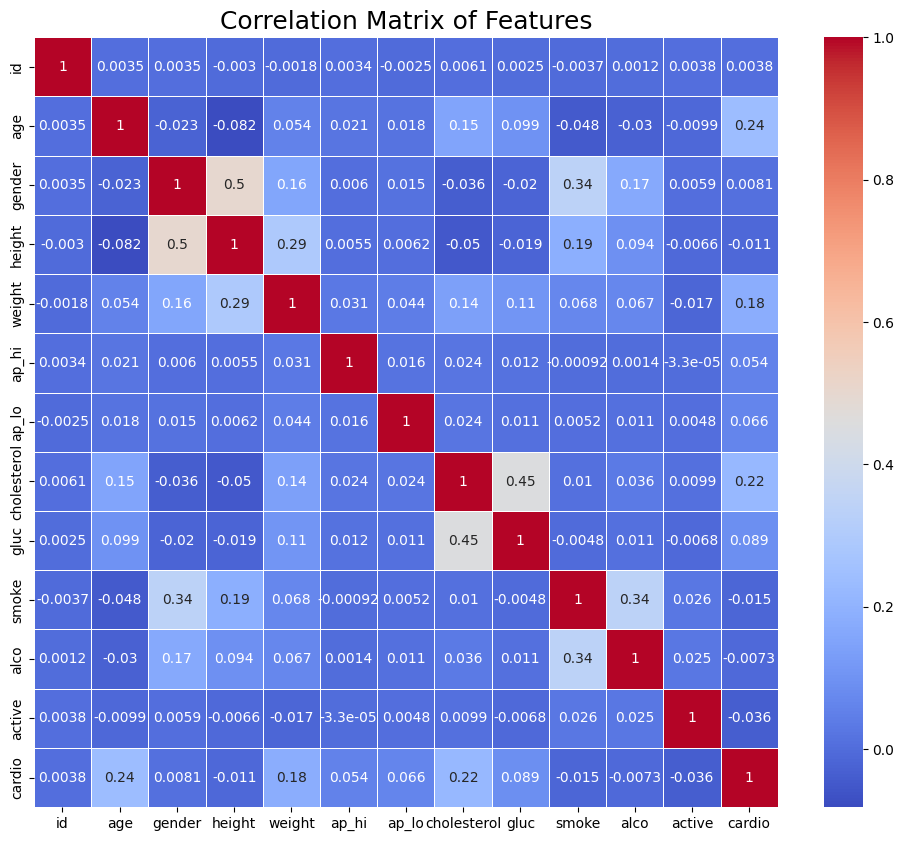

In [10]:
plt.figure(figsize=(12, 10))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Features", fontsize=18)
plt.show()

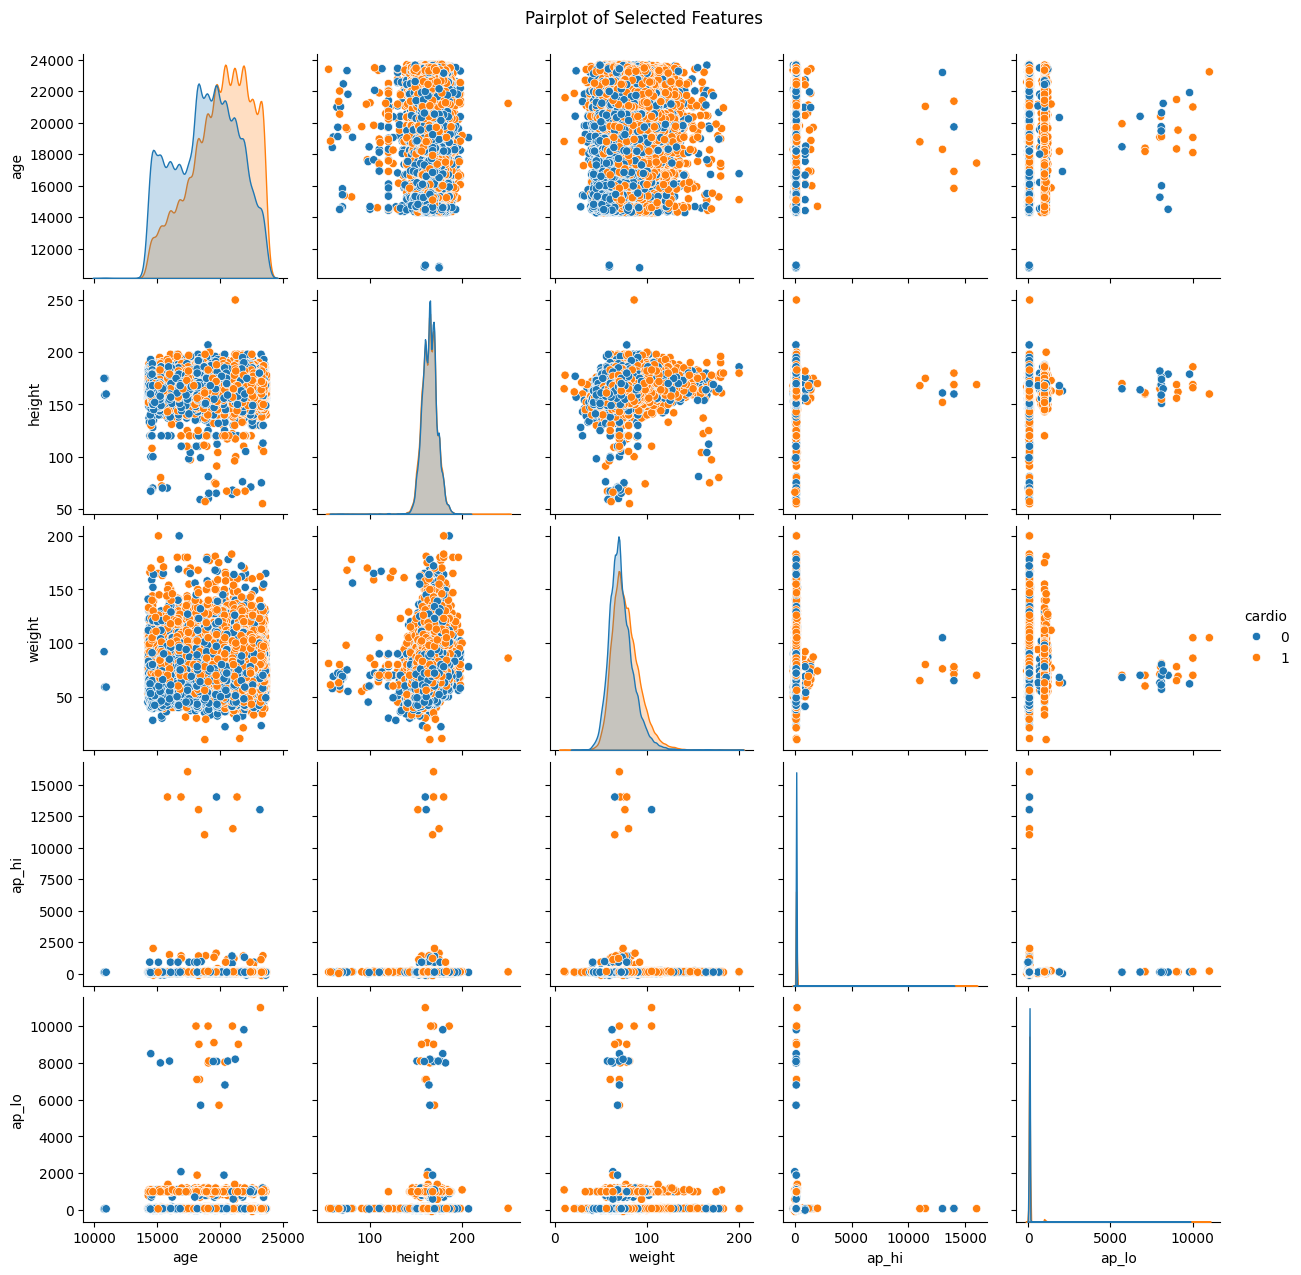

In [11]:
subset = df[["age", "height", "weight", "ap_hi", "ap_lo", "cardio"]]

sns.pairplot(subset, hue="cardio", diag_kind="kde")
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

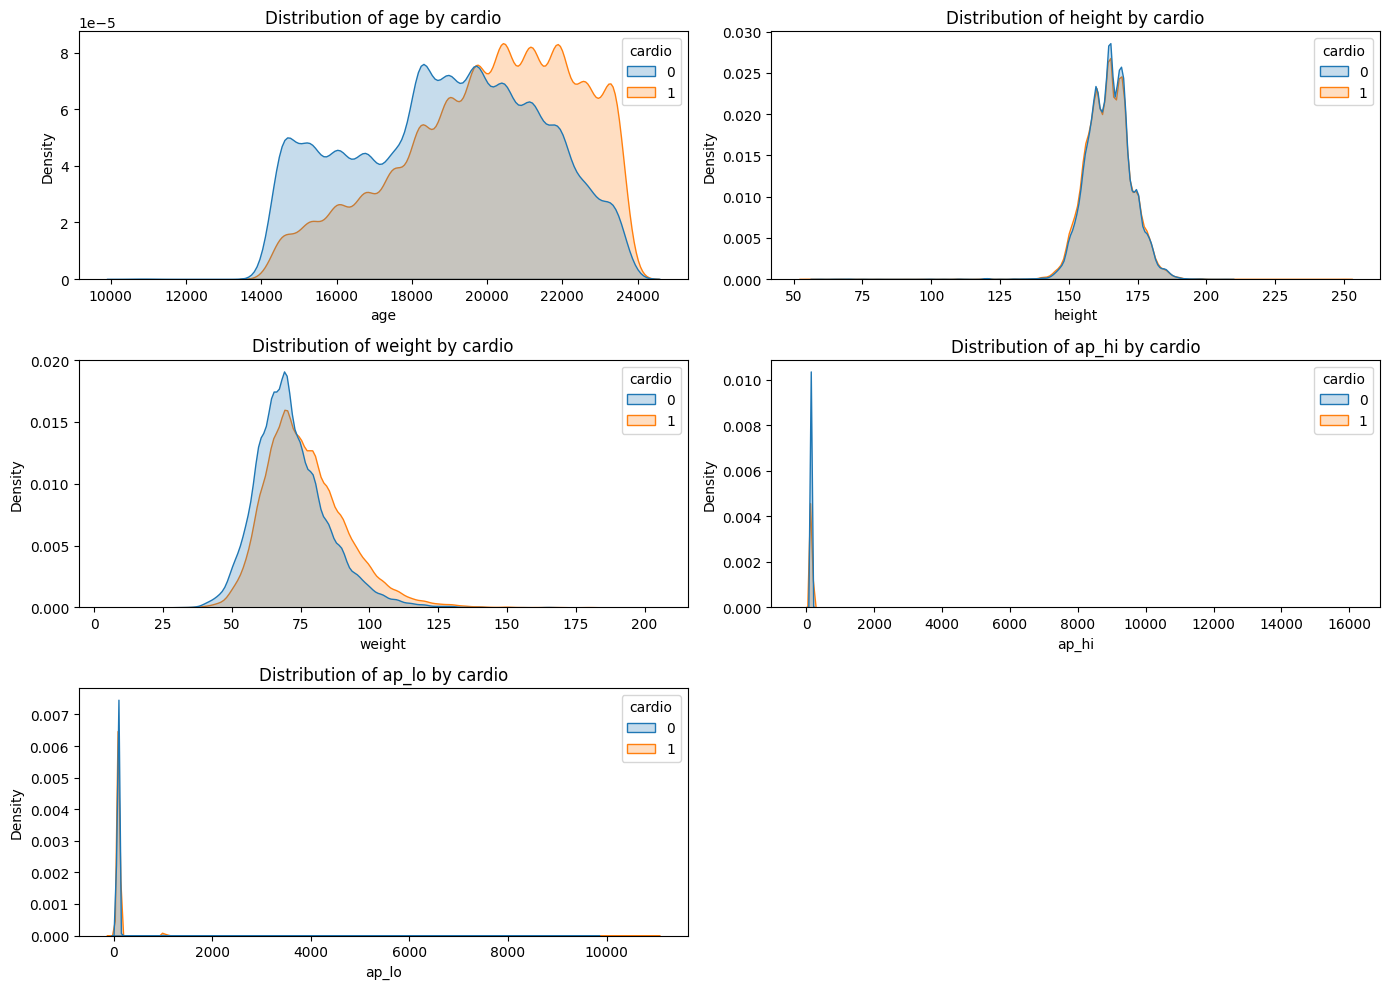

In [12]:
important_features = ["age", "height", "weight", "ap_hi", "ap_lo"]

plt.figure(figsize=(14, 10))
for i, col in enumerate(important_features, 1):
    plt.subplot(3, 2, i)
    sns.kdeplot(data=df, x=col, hue="cardio", fill=True)
    plt.title(f"Distribution of {col} by cardio")
plt.tight_layout()
plt.show()


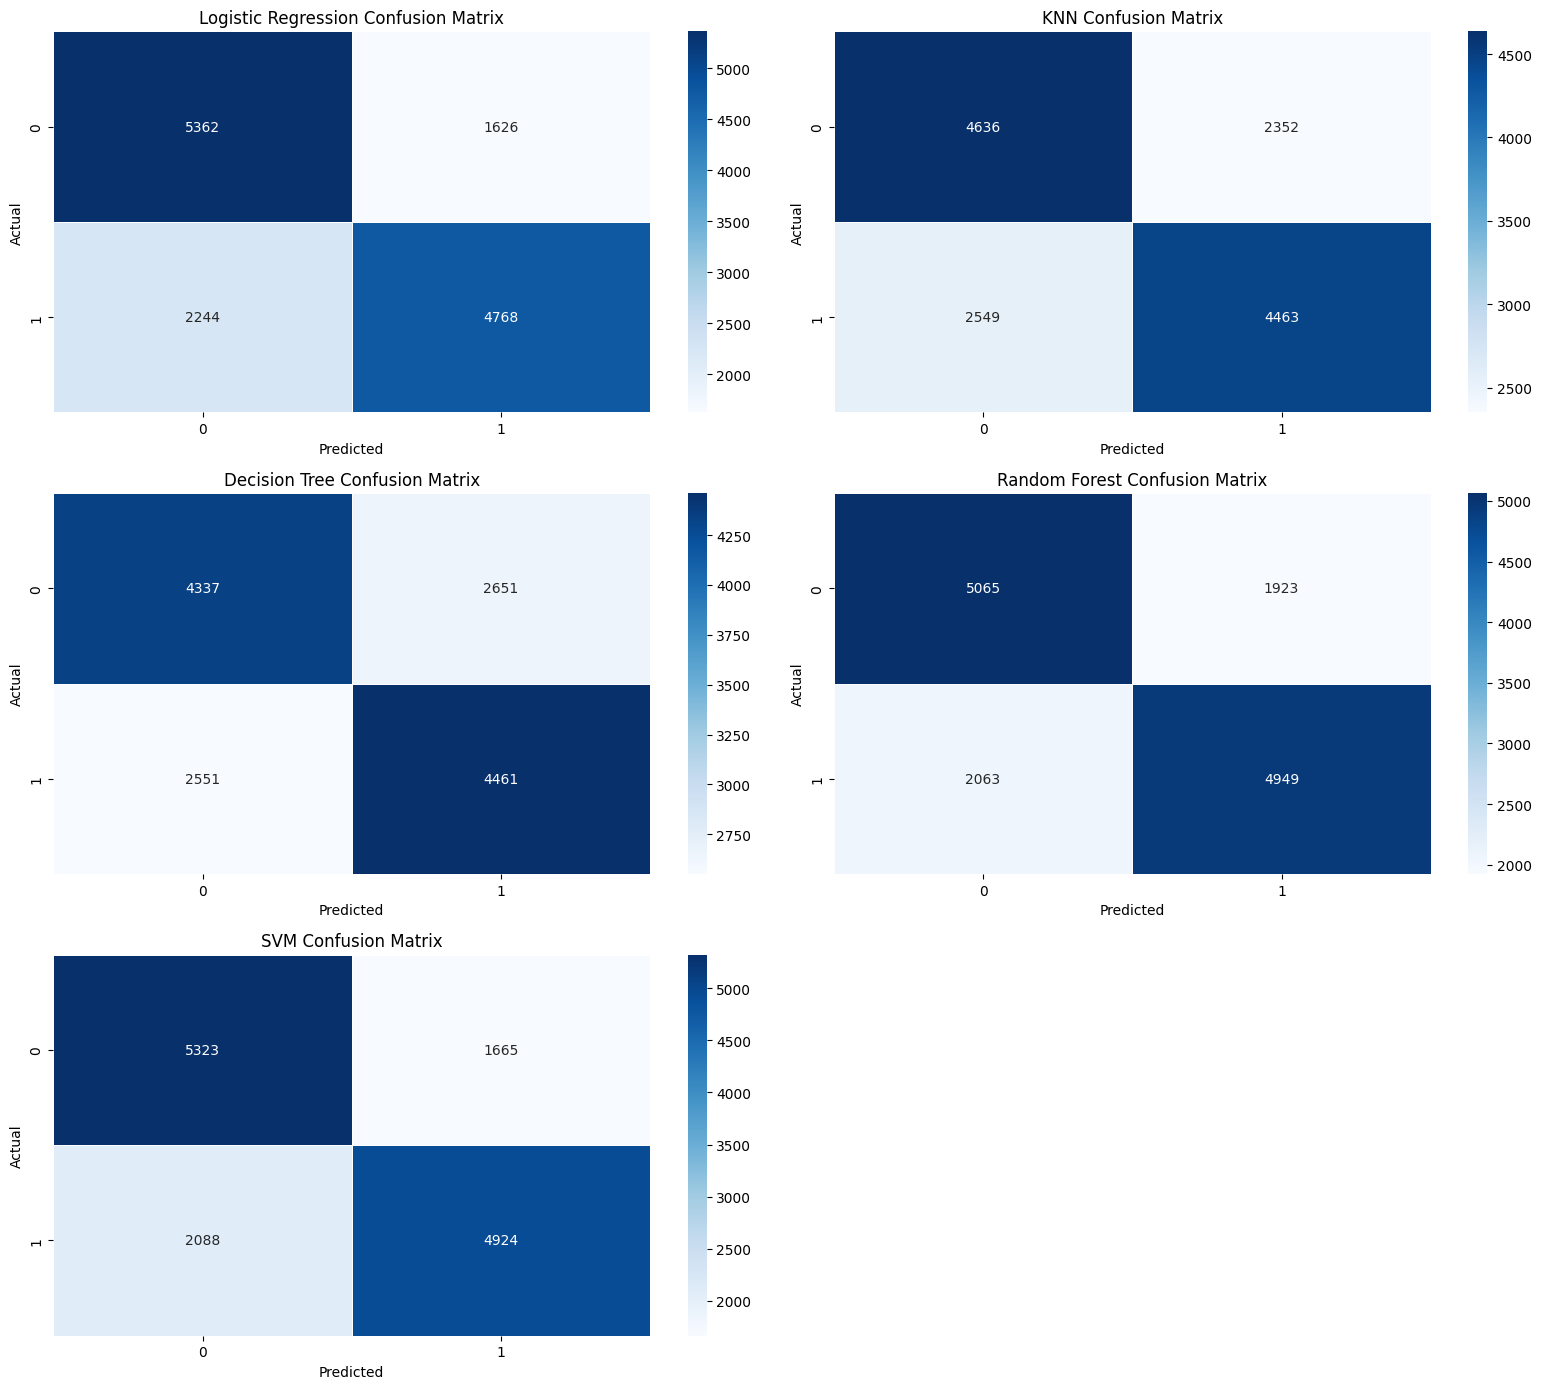

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Dictionary to store models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC()
}

plt.figure(figsize=(16, 14))

for i, (name, model) in enumerate(models.items(), 1):
    # Train model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    plt.subplot(3, 2, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", linewidths=0.5)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()


In [14]:
accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc
    print(f"{name}: {acc:.4f}")
best = max(accuracies, key=accuracies.get)
print("\nBest Model =", best)

Logistic Regression: 0.7236
KNN: 0.6499
Decision Tree: 0.6284
Random Forest: 0.7153
SVM: 0.7319

Best Model = SVM


In [17]:
!pip install pyngrok

In [26]:
!pip install pyngrok streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 78.5 MB/s eta 0:00:00


In [27]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import io
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

st.set_page_config(layout="wide", page_title="Heart Disease Prediction")

st.title("❤️ Heart Disease Prediction — Full App")
st.markdown("Upload your semicolon-separated CSV (the app auto-fixes it).")

@st.cache_data
def load_and_fix(uploaded):
    # read raw bytes into a dataframe with single column
    raw = pd.read_csv(uploaded, header=None)
    s = raw.iloc[:,0].astype(str)
    df = s.str.split(";", expand=True)
    df.columns = [
        "id","age","gender","height","weight",
        "ap_hi","ap_lo","cholesterol","gluc",
        "smoke","alco","active","cardio"
    ]
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna().reset_index(drop=True)
    return df

def train_and_evaluate(df):
    X = df.drop(columns=['id','cardio'])
    y = df['cardio'].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    models = {
        'LogisticRegression': LogisticRegression(max_iter=2000),
        'KNN': KNeighborsClassifier(),
        'DecisionTree': DecisionTreeClassifier(random_state=42),
        'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
        'SVM': SVC(probability=True, random_state=42)
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = {}
    for name, m in models.items():
        try:
            scores = cross_val_score(m, X_train_s, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
            cv_results[name] = (scores.mean(), scores.std())
        except Exception:
            cv_results[name] = (np.nan, np.nan)

    results = {}
    trained = {}
    artifacts = {}
    for name, m in models.items():
        try:
            m.fit(X_train_s, y_train)
            y_pred = m.predict(X_test_s)
            y_proba = m.predict_proba(X_test_s)[:,1] if hasattr(m, 'predict_proba') else None

            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            roc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

            results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc}
            trained[name] = m

            cm = confusion_matrix(y_test, y_pred)
            artifacts[name] = {'confusion': cm, 'y_test': y_test, 'y_proba': y_proba}
        except Exception as e:
            results[name] = {'accuracy': np.nan, 'precision': np.nan, 'recall': np.nan, 'f1': np.nan, 'roc_auc': np.nan}

    return {'scaler': scaler, 'models': models, 'trained': trained, 'results': results, 'cv': cv_results, 'artifacts': artifacts, 'X_columns': list(X.columns)}

def plot_confusion(cm):
    fig, ax = plt.subplots(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    return fig

def plot_roc(y_true, y_proba):
    if y_proba is None:
        return None
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    fig, ax = plt.subplots(figsize=(5,4))
    ax.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_true, y_proba):.3f}")
    ax.plot([0,1],[0,1],'--', color='gray')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    return fig

uploaded = st.file_uploader("Upload semicolon CSV", type=["csv"])
if uploaded:
    df = load_and_fix(uploaded)
    st.subheader("Sample rows")
    st.dataframe(df.head())

    st.subheader("Basic statistics")
    st.write(df.describe())

    # EDA plots collapsible
    with st.expander("Show EDA Plots"):
        st.write("Histograms (numeric features)")
        num_cols = ['age','height','weight','ap_hi','ap_lo']
        fig, axes = plt.subplots(2,3, figsize=(12,7))
        axes = axes.flatten()
        for i, c in enumerate(num_cols):
            sns.histplot(df[c], kde=True, ax=axes[i])
            axes[i].set_title(c)
        axes[-1].axis('off')
        st.pyplot(fig)

        st.write("Correlation matrix")
        fig2, ax2 = plt.subplots(figsize=(8,6))
        sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax2)
        st.pyplot(fig2)

    # Train models and show results
    if st.button("Train & Evaluate Models"):
        with st.spinner("Training models... (may take 20-60s)"):
            out = train_and_evaluate(df)
        st.success("Training complete")

        # Show cross-val summary
        st.subheader("Cross-Validation (train set) — mean ± std")
        cv_df = pd.DataFrame(out['cv'], index=None).T
        cv_df.columns = ['mean', 'std']
        st.dataframe(cv_df)

        st.subheader("Test set results")
        res_df = pd.DataFrame(out['results']).T
        st.dataframe(res_df.style.format("{:.4f}"))

        # show confusion matrices and ROC
        st.subheader("Confusion Matrices and ROC Curves")
        cols = st.columns(2)
        for i, (name, art) in enumerate(out['artifacts'].items()):
            cm = art['confusion']
            y_test = art['y_test']
            y_proba = art['y_proba']
            fig_cm = plot_confusion(cm)
            fig_roc = plot_roc(y_test, y_proba)
            with cols[i%2]:
                st.markdown(f"**{name}**")
                st.pyplot(fig_cm)
                if fig_roc:
                    st.pyplot(fig_roc)

        # Save results and best model
        results_df = pd.DataFrame(out['results']).T
        best_name = results_df['accuracy'].idxmax()
        st.success(f"Best model by test accuracy: {best_name}")

        # Retrain best model on full data and save
        scaler_full = out['scaler']
        X_full = df.drop(columns=['id','cardio'])
        y_full = df['cardio'].astype(int)
        X_full_s = scaler_full.fit_transform(X_full)
        best_est_class = type(out['trained'][best_name])
        best_params = out['trained'][best_name].get_params()
        best_model_full = best_est_class(**best_params)
        best_model_full.fit(X_full_s, y_full)

        model_bundle = {'scaler': scaler_full, 'model': best_model_full, 'features': out['X_columns']}
        save_path = "best_model_cardio.joblib"
        joblib.dump(model_bundle, save_path)
        st.write("Saved best model to:", save_path)

        # Provide download link
        with open(save_path, 'rb') as f:
            bytes_data = f.read()
            st.download_button("Download best model (.joblib)", data=bytes_data, file_name=save_path)

        # Keep object in session_state for predictions
        st.session_state['model_bundle'] = model_bundle

# Prediction UI if model exists in session_state or loaded manually
st.subheader("Predict for a single patient")
if 'model_bundle' in st.session_state:
    mb = st.session_state['model_bundle']
    feats = mb['features']
    # create inputs in same order
    vals = {}
    for f in feats:
        # set sensible defaults
        if f == 'age':
            vals[f] = st.number_input("Age", min_value=1, max_value=120, value=50)
        elif f == 'gender':
            vals[f] = st.selectbox("Gender (1=female,2=male)", [1,2], index=0)
        elif f == 'height':
            vals[f] = st.number_input("Height (cm)", min_value=100, max_value=250, value=165)
        elif f == 'weight':
            vals[f] = st.number_input("Weight (kg)", min_value=20, max_value=200, value=65)
        elif f == 'ap_hi':
            vals[f] = st.number_input("Systolic BP (ap_hi)", min_value=50, max_value=260, value=120)
        elif f == 'ap_lo':
            vals[f] = st.number_input("Diastolic BP (ap_lo)", min_value=40, max_value=200, value=80)
        elif f == 'cholesterol':
            vals[f] = st.selectbox("Cholesterol (1,2,3)", [1,2,3], index=0)
        elif f == 'gluc':
            vals[f] = st.selectbox("Glucose (1,2,3)", [1,2,3], index=0)
        else:
            # smoke, alco, active
            vals[f] = st.selectbox(f, [0,1], index=0)

    if st.button("Predict using saved best model"):
        input_df = pd.DataFrame([[vals[c] for c in feats]], columns=feats)
        Xs = mb['scaler'].transform(input_df)
        pred = mb['model'].predict(Xs)[0]
        prob = mb['model'].predict_proba(Xs)[:,1][0] if hasattr(mb['model'],'predict_proba') else None
        if pred == 1:
            st.error(f"Prediction: High chance of heart disease (label=1). Probability={prob if prob is not None else 'N/A'}")
        else:
            st.success(f"Prediction: Low chance of heart disease (label=0). Probability={prob if prob is not None else 'N/A'}")
else:
    st.info("Train & save a model first (upload dataset and press 'Train & Evaluate Models').")


Writing app.py


In [37]:
!nohup streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /dev/null 2>&1 &

In [38]:
from pyngrok import ngrok
ngrok.set_auth_token("36SfQkGJ3vquGWjhSMJl84cnC8p_3UpPu9eRNhWzbBfZLTQuo")
ngrok.kill()
public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://chance-surly-brecken.ngrok-free.dev" -> "http://localhost:8501">